# Smart Navigation System: Graph-Based Route Optimization

This project implements urban route optimization using graph theory and shortest path algorithms.

The system uses Surabaya road network data from OpenStreetMap and compares three algorithms:

- Dijkstra Algorithm
- Breadth-First Search (BFS)
- Depth-First Search (DFS)

The objective is to analyze algorithm performance in finding optimal routes based on real-world road characteristics.

# 1. Fetching Road Network Data using OSMnx

This stage collects real-world road network data from OpenStreetMap (OSM) using the OSMnx library.  
The road network of Surabaya is extracted as a graph structure consisting of:

- **Nodes** → intersections / road points
- **Edges** → road segments connecting nodes

Additional road attributes are processed, including:
- Distance (meters)
- Average speed
- Travel time
- Traffic signal delay
- Maneuver penalty (turning cost)

The final edge weight represents estimated travel cost and will be used for shortest path calculation.

In [ ]:
import osmnx as ox
import pandas as pd
import os
import math

PLACE      = "Surabaya, East Java, Indonesia"
NETWORK    = "drive"
OUT_DIR    = "data"
NODES_FILE = f"{OUT_DIR}/nodes_raw.csv"
EDGES_FILE = f"{OUT_DIR}/edges_raw.csv"

os.makedirs(OUT_DIR, exist_ok=True)

# Fetch
print(f"[1/3] Fetching OSMnx graph: {PLACE} ...")
G = ox.graph_from_place(PLACE, network_type=NETWORK, simplify=True)
print(f"      Nodes: {len(G.nodes)}, Edges: {len(G.edges)}")

# Nodes 
print(f"[2/3] Menyimpan nodes → {NODES_FILE} ...")
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
nodes_df = nodes_gdf[["y", "x"]].reset_index()
nodes_df.columns = ["osmid", "lat", "lon"]
node_lookup = nodes_df.set_index("osmid")
nodes_df.to_csv(NODES_FILE, index=False)
print(f"      {len(nodes_df)} node tersimpan.")

# Edges + geometry
print(f"[3/3] Menyimpan edges + geometry → {EDGES_FILE} ...")
edges_gdf = edges_gdf.reset_index()

def parse_speed(val):
    if isinstance(val, (list, tuple)):
        if len(val) == 0:
            return 40
        val = val[0]
    try:
        import numpy as np
        if isinstance(val, np.ndarray):
            if len(val) == 0:
                return 40
            val = val[0]
    except:
        pass
    if pd.isna(val):
        return 40
    try:
        text = str(val)
        text = text.split(";")[0]
        text = text.split()[0]
        speed = float(text)
        if speed <= 0:
            return 40
        return speed
    except:
        return 40

def parse_name(val):
    if isinstance(val, list): return val[0]
    return str(val) if not pd.isna(val) else "Unknown"

edges_gdf["speed_kmh"] = edges_gdf["maxspeed"].apply(parse_speed) if "maxspeed" in edges_gdf.columns else 40
edges_gdf["road_name"] = edges_gdf["name"].apply(parse_name)      if "name"     in edges_gdf.columns else "Unknown"
edges_gdf["dist_m"]    = edges_gdf["length"].round(1)

# TRAFFIC SIGNAL DETECTION
traffic_signal_nodes = set()
if "highway" in nodes_gdf.columns:
    signal_nodes = nodes_gdf[
        nodes_gdf["highway"] == "traffic_signals"]
    traffic_signal_nodes = set(signal_nodes.index)

# Delay traffic light
edges_gdf["traffic_light_delay_sec"] = edges_gdf["v"].apply(
    lambda x: 15 if x in traffic_signal_nodes else 0)

# MANEUVER DETECTION Berdasarkan arah geometry jalan
def calculate_bearing(lat1, lon1, lat2, lon2):
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    dlon = math.radians(lon2 - lon1)
    x = math.sin(dlon) * math.cos(lat2)
    y = (
        math.cos(lat1) * math.sin(lat2)
        - math.sin(lat1)
        * math.cos(lat2)
        * math.cos(dlon))
    bearing = math.degrees(math.atan2(x, y))
    return (bearing + 360) % 360

def detect_maneuver(row):
    try:
        u = row["u"]
        v = row["v"]
        lat1 = node_lookup.loc[u, "lat"]
        lon1 = node_lookup.loc[u, "lon"]
        lat2 = node_lookup.loc[v, "lat"]
        lon2 = node_lookup.loc[v, "lon"]
        bearing = calculate_bearing(lat1,lon1,lat2,lon2)
        # kanan
        if 45 <= bearing < 135:
            return "right", 10
        # kiri
        elif 225 <= bearing < 315:
            return "left", 5
        # lurus
        else:
            return "straight", 3
    except:
        return "straight", 3

maneuver_data = edges_gdf.apply(detect_maneuver,axis=1,result_type="expand")
edges_gdf["maneuver"] = maneuver_data[0]
edges_gdf["maneuver_penalty_sec"] = maneuver_data[1]

# waktu dasar perjalanan
edges_gdf["travel_time_sec"] = (3.6 * edges_gdf["dist_m"]) / edges_gdf["speed_kmh"]

edges_gdf["intersection_delay_sec"] = edges_gdf.apply(
    lambda r:
        r["traffic_light_delay_sec"]
        if r["traffic_light_delay_sec"] > 0
        else r["maneuver_penalty_sec"],
    axis=1
)

# total final weight
edges_gdf["total_time_sec"] = (edges_gdf["travel_time_sec"]+ edges_gdf["intersection_delay_sec"])

edges_gdf["oneway"]    = edges_gdf["oneway"].fillna(False)         if "oneway"   in edges_gdf.columns else False

# Simpan geometry
edges_gdf["geometry_wkt"] = edges_gdf["geometry"].apply(
    lambda g: g.wkt if g is not None else ""
)

out_cols = [
    "u",
    "v",
    "dist_m",
    "speed_kmh",
    "travel_time_sec",
    "traffic_light_delay_sec",
    "maneuver",
    "maneuver_penalty_sec",
    "intersection_delay_sec",
    "total_time_sec",
    "road_name",
    "oneway",
    "geometry_wkt"
]
edges_gdf[out_cols].to_csv(EDGES_FILE, index=False)
print(f"{len(edges_gdf)} edge tersimpan (dengan geometry).")

print("\n Selesai!")
print(f"{NODES_FILE}")
print(f"{EDGES_FILE}")

[1/3] Fetching OSMnx graph: Surabaya, East Java, Indonesia ...
      Nodes: 36659, Edges: 89150
[2/3] Menyimpan nodes → data/nodes_raw.csv ...
      36659 node tersimpan.
[3/3] Menyimpan edges + geometry → data/edges_raw.csv ...
89150 edge tersimpan (dengan geometry).

 Selesai!
data/nodes_raw.csv
data/edges_raw.csv


# 2. Graph Data Transformation

This stage transforms the raw OSMnx graph into a simplified landmark-based graph.

The process includes:
1. Mapping selected Surabaya landmarks to the nearest OSM nodes.
2. Building an adjacency list representation.
3. Connecting landmarks through available road paths.
4. Saving processed nodes, edges, and geometry data.

The adjacency list is used because urban road networks are sparse graphs, making this structure more memory-efficient and faster for traversal algorithms.

In [1]:
import pandas as pd
import numpy as np
import json, os, math, warnings
from collections import deque
from shapely import wkt as shapely_wkt
warnings.filterwarnings("ignore")

IN_NODES      = "data/nodes_raw.csv"
IN_EDGES      = "data/edges_raw.csv"
OUT_NODES     = "data/nodes.csv"
OUT_EDGES     = "data/edges.csv"
OUT_GEOM      = "data/edges_geometry.csv"

# 40 LANDMARK SURABAYA
LANDMARKS = [
    ("UNESA Ketintang",            -7.312792, 112.728529, "kampus"),
    ("ITS Sukolilo",               -7.290652, 112.791751, "kampus"),
    ("Universitas Airlangga",      -7.269996, 112.782223, "kampus"), 
    ("Universitas Surabaya",       -7.3019, 112.7780, "kampus"),
    ("Universitas Negeri UM",      -7.2675, 112.7340, "kampus"),
    ("STTS Surabaya",              -7.2611, 112.7512, "kampus"),
    ("Tunjungan Plaza",            -7.2577, 112.7376, "mall"),
    ("Grand City Mall",            -7.2480, 112.7512, "mall"),
    ("Galaxy Mall",                -7.2913, 112.7805, "mall"),
    ("BG Junction",                -7.255983, 112.734236, "mall"),
    ("Ciputra World",              -7.291751, 112.7186, "mall"),
    ("Royal Plaza",                -7.310458, 112.734864, "mall"), 
    ("Stasiun Gubeng",             -7.2653, 112.7522, "transportasi"),
    ("Stasiun Pasar Turi",         -7.2448, 112.7266, "transportasi"),
    ("Terminal Bungurasih",        -7.35349, 112.722435, "transportasi"),
    ("Terminal Wonokromo",         -7.3003, 112.7318, "transportasi"),
    ("Pelabuhan Tanjung Perak",    -7.2014, 112.7283, "transportasi"),
    ("RSUD Dr. Soetomo",           -7.2690, 112.7503, "rumahsakit"),
    ("RS Premier Surabaya",        -7.3025, 112.7658, "rumahsakit"),
    ("RS Siloam Surabaya",         -7.2610, 112.7411, "rumahsakit"),
    ("Balai Kota Surabaya",        -7.2492, 112.7376, "pemerintahan"),
    ("Tugu Pahlawan",              -7.247186, 112.73859, "landmark"), 
    ("Masjid Al-Akbar",            -7.33543, 112.716648, "landmark"), 
    ("Kebun Binatang Surabaya",    -7.2949, 112.7307, "wisata"),
    ("Monkasel Surabaya",          -7.2643, 112.7479, "wisata"),
    ("House of Sampoerna",         -7.2387, 112.7310, "wisata"),
    ("Simpang Jl. Ahmad Yani",     -7.326419, 112.731315, "persimpangan"),
    ("Simpang Wonokromo",          -7.300831, 112.737107, "persimpangan"),
    ("Simpang Darmo - Polda",      -7.2839, 112.7350, "persimpangan"),
    ("Simpang Urip Sumoharjo",     -7.2720, 112.7320, "persimpangan"),
    ("Simpang Basuki Rahmat",      -7.2622, 112.7388, "persimpangan"),
    ("Simpang Embong Malang",      -7.2590, 112.7340, "persimpangan"),
    ("Simpang Pemuda - Gubernur",  -7.2550, 112.7450, "persimpangan"),
    ("Bundaran Waru",              -7.346099, 112.729253, "persimpangan"),
    ("Simpang Kenjeran",           -7.245422, 112.768848, "persimpangan"),
    ("Simpang Jl. Diponegoro",     -7.2780, 112.7460, "persimpangan"),
    ("Simpang Raya Darmo",         -7.2910, 112.7360, "persimpangan"),
    ("Simpang Joyoboyo",           -7.3060, 112.7290, "persimpangan"),
    ("Simpang HR Muhammad",        -7.2915, 112.7550, "persimpangan"),
    ("Simpang Mulyosari",          -7.2550, 112.7850, "persimpangan"),
]

# HELPERS
def haversine(lat1, lon1, lat2, lon2):
    R = 6_371_000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2-lat1); dl = math.radians(lon2-lon1)
    a  = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def snap_to_nearest(lat, lon, nodes_df):
    df = nodes_df.copy()
    df["dist"] = df.apply(lambda r: haversine(lat, lon, r["lat"], r["lon"]), axis=1)
    return df.nsmallest(1, "dist").iloc[0]

def geometry_wkt_to_coords(wkt_str):
    """WKT LineString → list of [lon, lat]"""
    try:
        geom = shapely_wkt.loads(wkt_str)
        return [[round(x, 6), round(y, 6)] for x, y in geom.coords]
    except:
        return []

def bfs_path_with_geom(adj, src, dst, max_steps=10000):
    """BFS — kembalikan list edge dict (termasuk geometry coords)."""
    if src == dst: return []
    visited = {src}
    q = deque([(src, [])])
    steps = 0
    while q:
        cur, path = q.popleft()
        steps += 1
        if steps > max_steps: return None
        for e in adj.get(cur, []):
            nb = e["v"]
            if nb == dst:
                return path + [e]
            if nb not in visited:
                visited.add(nb)
                q.append((nb, path + [e]))
    return None

# LOAD RAW DATA
print("[1/5] Membaca data mentah OSMnx ...")
nodes_raw = pd.read_csv(IN_NODES)
edges_raw = pd.read_csv(IN_EDGES)
print(f"      {len(nodes_raw)} nodes, {len(edges_raw)} edges")

# SNAP LANDMARKS → OSMID
print("[2/5] Snap 40 landmark ke OSMnx node terdekat ...")
landmark_rows = []
osmid_to_name = {}

for (name, lat, lon, tipe) in LANDMARKS:
    nearest     = snap_to_nearest(lat, lon, nodes_raw)
    osmid       = int(nearest["osmid"])
    slat, slon  = float(nearest["lat"]), float(nearest["lon"])
    snap_d      = haversine(lat, lon, slat, slon)
    landmark_rows.append({"name": name, "lat": slat, "lon": slon,
                           "type": tipe, "osmid": osmid,
                           "snap_dist_m": round(snap_d, 1)})
    osmid_to_name[osmid] = name
    print(f"{name:<35} → {osmid} ({snap_d:.0f} m)")

nodes_out = pd.DataFrame(landmark_rows)

# BANGUN ADJACENCY — SERTAKAN GEOMETRY COORDS
print("\n[3/5] Membangun adjacency list dengan geometry ...")
adj = {}   # osmid → list of {v, dist_m, speed_kmh, road_name, coords}

for _, row in edges_raw.iterrows():
    u   = int(row["u"]); v = int(row["v"])
    d   = float(row["dist_m"])
    spd = float(row["speed_kmh"]) if not pd.isna(row["speed_kmh"]) else 40.0
    rn  = str(row["road_name"])
    ow  = bool(row["oneway"]) if "oneway" in row else False

    # Parse geometry: WKT → [[lon,lat], ...]
    coords_fwd = geometry_wkt_to_coords(str(row.get("geometry_wkt", "")))
    coords_rev = list(reversed(coords_fwd))   # untuk arah balik

    edge_fwd = {
    "v": v,
    "dist_m": d,
    "speed_kmh": spd,
    "travel_time_sec": float(
        row.get("travel_time_sec", 0)),
    "traffic_light_delay_sec": float(
        row.get("traffic_light_delay_sec", 0)),
    "maneuver_penalty_sec": float(
        row.get("maneuver_penalty_sec", 0)),
    "intersection_delay_sec": float(
        row.get("intersection_delay_sec", 0)),
    "weight": float(
        row.get("total_time_sec", 0)),
    "road_name": rn,
    "coords": coords_fwd,
    "maneuver": str(
        row.get("maneuver", "straight")),
    }
    edge_rev = {
    "v": u,
    "dist_m": d,
    "speed_kmh": spd,
    "travel_time_sec": float(
        row.get("travel_time_sec", 0)),
    "traffic_light_delay_sec": float(
        row.get("traffic_light_delay_sec", 0)),
    "maneuver_penalty_sec": float(
        row.get("maneuver_penalty_sec", 0)),
    "intersection_delay_sec": float(
        row.get("intersection_delay_sec", 0)),
    "weight": float(
        row.get("total_time_sec", 0)),
    "road_name": rn,
    "coords": coords_rev,
    "maneuver": str(
        row.get("maneuver", "straight")),
}

    adj.setdefault(u, []).append(edge_fwd)
    if not ow:
        adj.setdefault(v, []).append(edge_rev)

print(f"Adjacency siap: {len(adj)} OSM node")

# TEMUKAN EDGE ANTAR LANDMARK + KUMPULKAN GEOMETRY
print("\n[4/5] Mencari koneksi + geometry antar 40 landmark via BFS ...")
osmid_list = [r["osmid"] for r in landmark_rows]
name_list  = [r["name"]  for r in landmark_rows]
edge_rows  = []
geom_rows  = []
found = skipped = 0

for i, src in enumerate(osmid_list):
    for j, dst in enumerate(osmid_list[i+1:], start=i+1):
        path_edges = bfs_path_with_geom(adj, src, dst)
        if path_edges is None:
            skipped += 1; continue

        total_dist = sum(e["dist_m"] for e in path_edges)
        avg_speed  = float(np.mean([e["speed_kmh"] for e in path_edges])) if path_edges else 40.0
        road_name  = path_edges[0]["road_name"] if path_edges else "Unknown"

        # Filter jarak terlalu muter
        direct_m = haversine(
            nodes_out.iloc[i]["lat"], nodes_out.iloc[i]["lon"],
            nodes_out.iloc[j]["lat"], nodes_out.iloc[j]["lon"],
        )
        if total_dist > max(direct_m * 4, 500):
            skipped += 1; continue

        src_name = name_list[i]
        dst_name = name_list[j]
        weight = round(sum(e["weight"] for e in path_edges),2)

        edge_rows.append({
            "from": src_name, "to": dst_name,
            "dist_m": round(total_dist, 1), "speed_kmh": round(avg_speed, 1),
            "weight_sec": weight, "road_name": road_name,
            "travel_time_sec": round(sum(e["travel_time_sec"] for e in path_edges),1),
            "traffic_light_delay_sec": round(sum(e["traffic_light_delay_sec"] for e in path_edges),1),
            "maneuver_delay_sec": round(sum(e["maneuver_penalty_sec"] for e in path_edges),1),
            "intersection_delay_sec": round(sum(e["intersection_delay_sec"] for e in path_edges),1),
            "left_turn_count": sum(1 for e in path_edges if e.get("maneuver") == "left"),
            "right_turn_count": sum(1 for e in path_edges if e.get("maneuver") == "right"),
            "straight_count": sum(1 for e in path_edges if e.get("maneuver") == "straight"),
        })

        # Gabung semua koordinat sepanjang jalur menjadi satu polyline
        full_coords = []
        for e in path_edges:
            c = e.get("coords", [])
            if not c:
                continue
            # Hindari duplikasi titik sambungan antar segmen
            if full_coords and c[0] == full_coords[-1]:
                full_coords.extend(c[1:])
            else:
                full_coords.extend(c)

        geom_rows.append({
            "from":        src_name,
            "to":          dst_name,
            "coords_json": json.dumps(full_coords),
        })
        found += 1

print(f"{found} edge ditemukan, {skipped} dilewati")

# SIMPAN OUTPUT
print(f"\n[5/5] Menyimpan ...")
nodes_out.to_csv(OUT_NODES, index=False)
pd.DataFrame(edge_rows).to_csv(OUT_EDGES, index=False)
pd.DataFrame(geom_rows).to_csv(OUT_GEOM,  index=False)

print(f"{OUT_NODES}  ({len(nodes_out)} node)")
print(f"{OUT_EDGES}  ({len(edge_rows)} edge)")
print(f"{OUT_GEOM}   ({len(geom_rows)} polyline)")
print("\nTransformasi selesai!")

[1/5] Membaca data mentah OSMnx ...
      36659 nodes, 89150 edges
[2/5] Snap 40 landmark ke OSMnx node terdekat ...
UNESA Ketintang                     → 4540778358 (143 m)
ITS Sukolilo                        → 1362379936 (35 m)
Universitas Airlangga               → 415832044 (2 m)
Universitas Surabaya                → 6862814076 (10 m)
Universitas Negeri UM               → 6829283784 (113 m)
STTS Surabaya                       → 1685005288 (46 m)
Tunjungan Plaza                     → 4465908463 (80 m)
Grand City Mall                     → 4478222232 (58 m)
Galaxy Mall                         → 4451570036 (60 m)
BG Junction                         → 270613355 (0 m)
Ciputra World                       → 420469015 (8 m)
Royal Plaza                         → 886386169 (2 m)
Stasiun Gubeng                      → 2304458296 (83 m)
Stasiun Pasar Turi                  → 4533089900 (72 m)
Terminal Bungurasih                 → 9620111085 (716 m)
Terminal Wonokromo                  → 3730492708

# 3. Implementation of Path Finding Algorithms

This section implements three graph algorithms:

### Dijkstra Algorithm
Finds the optimal route based on weighted edges using a priority queue (min-heap).  
The weight represents total travel time including road distance, speed, and delay factors.

Time Complexity:

O((V + E) log V)


### Breadth-First Search (BFS)
Explores nodes level-by-level using a queue data structure.

BFS finds the path with the fewest number of edges but does not consider road weights.

Time Complexity:

O(V + E)


### Depth-First Search (DFS)
Explores graph paths deeply using a stack structure.

DFS is useful for traversal but does not guarantee the shortest or fastest route.

Time Complexity:

O(V + E)

In [2]:
import heapq, os, time, json
import warnings
from collections import deque
from typing import Dict, List, Optional
import pandas as pd
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
warnings.filterwarnings("ignore")

# LOAD DATA DARI CSV
NODES_CSV = "data/nodes.csv"
EDGES_CSV = "data/edges.csv"
GEOM_CSV  = "data/edges_geometry.csv"

def load_data():
    nodes_df = pd.read_csv(NODES_CSV)
    edges_df = pd.read_csv(EDGES_CSV)

    # NODES: dict nama → {lat, lon, type}
    NODES = {
        row["name"]: {"lat": row["lat"], "lon": row["lon"], "type": row["type"]}
        for _, row in nodes_df.iterrows()
    }

    # GEOMETRY: dict (from,to) → [[lon,lat], ...]  (dua arah)
    GEOM = {}
    if os.path.exists(GEOM_CSV):
        geom_df = pd.read_csv(GEOM_CSV)
        for _, row in geom_df.iterrows():
            coords = json.loads(row["coords_json"])
            GEOM[(row["from"], row["to"])] = coords
            GEOM[(row["to"],  row["from"])] = list(reversed(coords))

    # EDGES: list of (from, to, dist_m, speed_kmh, road_name)
    EDGES_RAW = [
        (
            row["from"],
            row["to"],
            row["dist_m"],
            row["speed_kmh"],
            row["road_name"],
            row.get("travel_time_sec", 0),
            row.get("traffic_light_delay_sec", 0),
            row.get("maneuver_delay_sec", 0),
            row["weight_sec"]
        )

        for _, row in edges_df.iterrows()
    ]

    return NODES, EDGES_RAW, GEOM

# BANGUN GRAF
def build_graph(NODES, EDGES_RAW) -> Dict:
    """
    Adjacency list. Bobot = waktu tempuh (detik):
        td = (3.6 × dist_m) / speed_kmh
    """
    graph = {name: [] for name in NODES}
    for (u,v,dist_m,speed_kmh,road_name,travel_time,traffic_delay,maneuver_delay,weight_sec) in EDGES_RAW:
        if u not in graph or v not in graph:
            continue
        w = weight_sec
        edge_u = {"to": v, "weight": w, "dist_m": dist_m, "speed": speed_kmh, "road": road_name, "travel_time_sec": travel_time, "traffic_light_delay_sec": traffic_delay, "maneuver_delay_sec": maneuver_delay}
        edge_v = {"to": u, "weight": w, "dist_m": dist_m, "speed": speed_kmh, "road": road_name, "travel_time_sec": travel_time, "traffic_light_delay_sec": traffic_delay, "maneuver_delay_sec": maneuver_delay}
        graph[u].append(edge_u)
        graph[v].append(edge_v)
    return graph

# 1. DIJKSTRA
def dijkstra(graph, start, end) -> Dict:
    """Shortest path berdasarkan bobot waktu. O((V+E) log V)."""
    t0 = time.perf_counter()
    dist  = {n: float("inf") for n in graph}
    dist[start] = 0.0
    pred  = {n: None for n in graph}
    heap  = [(0.0, start)]
    visited = set()
    nodes_visited, n_exam = [], 0

    while heap:
        cur_d, cur = heapq.heappop(heap)
        if cur in visited: continue
        visited.add(cur); nodes_visited.append(cur); n_exam += 1
        if cur == end: break
        for e in graph.get(cur, []):
            nb = e["to"]
            if nb in visited: continue
            nd = cur_d + e["weight"]
            if nd < dist[nb]:
                dist[nb] = nd; pred[nb] = (cur, e)
                heapq.heappush(heap, (nd, nb))

    t_ms = (time.perf_counter() - t0) * 1000
    if dist[end] == float("inf"):
        return {"found": False, "algo": "Dijkstra", "nodes_examined": n_exam, "time_ms": t_ms}

    path, edges_used, cur = [], [], end
    while cur:
        path.append(cur)
        if pred[cur]: edges_used.append(pred[cur][1])
        cur = pred[cur][0] if pred[cur] else None
    path.reverse(); edges_used.reverse()

    return {"found": True, "algo": "Dijkstra", "path": path,
            "total_sec": dist[end], "total_min": dist[end]/60,
            "total_dist_m": sum(e["dist_m"] for e in edges_used),
            "edges": edges_used, "nodes_visited": nodes_visited,
            "nodes_examined": n_exam, "time_ms": t_ms}

# 2. BFS
def bfs(graph, start, end) -> Dict:
    """Shortest path berdasarkan jumlah hop (tanpa bobot). O(V+E)."""
    t0 = time.perf_counter()
    visited = {start}; pred = {start: None}
    queue = deque([start])
    nodes_visited, n_exam = [], 0

    while queue:
        cur = queue.popleft()
        nodes_visited.append(cur); n_exam += 1
        if cur == end: break
        for e in graph.get(cur, []):
            nb = e["to"]
            if nb not in visited:
                visited.add(nb); pred[nb] = (cur, e); queue.append(nb)

    t_ms = (time.perf_counter() - t0) * 1000
    if end not in pred:
        return {"found": False, "algo": "BFS", "nodes_examined": n_exam, "time_ms": t_ms}

    path, edges_used, cur = [], [], end
    while cur:
        path.append(cur)
        if pred[cur]: edges_used.append(pred[cur][1])
        cur = pred[cur][0] if pred[cur] else None
    path.reverse(); edges_used.reverse()
    total_sec = sum(e["weight"] for e in edges_used)

    return {"found": True, "algo": "BFS", "path": path,
            "total_sec": total_sec, "total_min": total_sec/60,
            "total_dist_m": sum(e["dist_m"] for e in edges_used),
            "edges": edges_used, "nodes_visited": nodes_visited,
            "nodes_examined": n_exam, "time_ms": t_ms}

# 3. DFS
def dfs(graph, start, end) -> Dict:
    """Path via depth-first (tidak menjamin optimal). O(V+E)."""
    t0 = time.perf_counter()
    visited = set(); pred = {start: None}
    stack = [start]
    nodes_visited, n_exam = [], 0

    while stack:
        cur = stack.pop()
        if cur in visited: continue
        visited.add(cur); nodes_visited.append(cur); n_exam += 1
        if cur == end: break
        for e in reversed(graph.get(cur, [])):
            nb = e["to"]
            if nb not in visited and nb not in pred:
                pred[nb] = (cur, e); stack.append(nb)

    t_ms = (time.perf_counter() - t0) * 1000
    if end not in pred and start != end:
        return {"found": False, "algo": "DFS", "nodes_examined": n_exam, "time_ms": t_ms}

    path, edges_used, cur = [], [], end
    while cur:
        path.append(cur)
        if pred[cur]: edges_used.append(pred[cur][1])
        cur = pred[cur][0] if pred[cur] else None
    path.reverse(); edges_used.reverse()
    total_sec = sum(e["weight"] for e in edges_used)

    return {"found": True, "algo": "DFS", "path": path,
            "total_sec": total_sec, "total_min": total_sec/60,
            "total_dist_m": sum(e["dist_m"] for e in edges_used),
            "edges": edges_used, "nodes_visited": nodes_visited,
            "nodes_examined": n_exam, "time_ms": t_ms}

# PERBANDINGAN
def compare_algorithms(graph, start, end) -> Dict:
    print(f"   Dijkstra ..."); r_d = dijkstra(graph, start, end)
    print(f"   BFS      ..."); r_b = bfs(graph, start, end)
    print(f"   DFS      ..."); r_f = dfs(graph, start, end)

    comp = {"Dijkstra": r_d, "BFS": r_b, "DFS": r_f, "start": start, "end": end}
    comp["same_path"] = {
        "Dijkstra == BFS": r_d.get("path") == r_b.get("path"),
        "Dijkstra == DFS": r_d.get("path") == r_f.get("path"),
        "BFS == DFS":      r_b.get("path") == r_f.get("path"),
    }
    times = {a: comp[a].get("time_ms", 9999) for a in ["Dijkstra","BFS","DFS"]}
    comp["fastest_algo"]      = min(times, key=times.get)
    comp["optimal_time_algo"] = "Dijkstra"
    return comp

# CETAK HASIL
def print_comparison(comp):
    start, end = comp["start"], comp["end"]
    print(f"\n{'='*65}")
    print(f"  PERBANDINGAN: DIJKSTRA vs BFS vs DFS")
    print(f"  Dari  : {start}")
    print(f"  Ke    : {end}")
    print(f"{'='*65}")

    for algo in ["Dijkstra","BFS","DFS"]:
        r = comp[algo]
        if not r.get("found"):
            print(f"  {algo}: RUTE TIDAK DITEMUKAN"); continue
        print(f"\n  [{algo}]")
        print(f"    Waktu Tempuh   : {r['total_min']:.2f} menit")
        print(f"    Total Jarak    : {r['total_dist_m']/1000:.3f} km")
        print(f"    Node Diperiksa : {r['nodes_examined']}")
        print(f"    Waktu Eksekusi : {r['time_ms']:.4f} ms")
        print(f"    Jalur          : {' → '.join(r['path'])}")

    print(f"\n{'─'*65}")
    print(f"  {'Metrik':<32} {'Dijkstra':>10} {'BFS':>10} {'DFS':>10}")
    print(f"  {'─'*62}")
    rows = [
        ("Waktu Tempuh (menit)",
         f"{comp['Dijkstra'].get('total_min',0):.2f}",
         f"{comp['BFS'].get('total_min',0):.2f}",
         f"{comp['DFS'].get('total_min',0):.2f}"),
        ("Jarak (km)",
         f"{comp['Dijkstra'].get('total_dist_m',0)/1000:.2f}",
         f"{comp['BFS'].get('total_dist_m',0)/1000:.2f}",
         f"{comp['DFS'].get('total_dist_m',0)/1000:.2f}"),
        ("Node Diperiksa",
         str(comp['Dijkstra'].get('nodes_examined',0)),
         str(comp['BFS'].get('nodes_examined',0)),
         str(comp['DFS'].get('nodes_examined',0))),
        ("Waktu Eksekusi (ms)",
         f"{comp['Dijkstra'].get('time_ms',0):.4f}",
         f"{comp['BFS'].get('time_ms',0):.4f}",
         f"{comp['DFS'].get('time_ms',0):.4f}"),
    ]
    for label, d, b, f in rows:
        print(f"  {label:<32} {d:>10} {b:>10} {f:>10}")

    print(f"\n  Jalur sama? Dijkstra==BFS: {'✅' if comp['same_path']['Dijkstra == BFS'] else '❌'}  "
          f"Dijkstra==DFS: {'✅' if comp['same_path']['Dijkstra == DFS'] else '❌'}  "
          f"BFS==DFS: {'✅' if comp['same_path']['BFS == DFS'] else '❌'}")
    print(f"  Tercepat       : {comp['fastest_algo']}")
    print(f"  Jalur optimal  : {comp['optimal_time_algo']}")
    print(f"{'='*65}\n")

# VISUALISASI
NODE_COLORS = {
    "kampus": "#2ECC71",
    "mall": "#3498DB",
    "transportasi": "#E74C3C",
    "rumahsakit": "#E67E22",
    "pemerintahan": "#9B59B6",
    "landmark": "#F39C12",
    "wisata": "#1ABC9C",
    "persimpangan": "#95A5A6",
}

ALGO_COLORS = {
    "Dijkstra": "#FF4757",
    "BFS": "#2ED573",
    "DFS": "#FFA502"
}

def plot_comparison(comp, graph, NODES, GEOM, save_path=None):
    fig = plt.figure(figsize=(24, 13))
    fig.patch.set_facecolor("#0d1117")
    # LAYOUT
    gs = fig.add_gridspec(
        4,
        3,
        width_ratios=[2.4, 1, 1],
        height_ratios=[0.85, 0.85, 0.85, 0.55],
        hspace=0.18,
        wspace=0.12
    )
    ax_map = fig.add_subplot(gs[:, 0])
    ax_dijkstra = fig.add_subplot(gs[0, 1:])
    ax_bfs      = fig.add_subplot(gs[1, 1:])
    ax_dfs      = fig.add_subplot(gs[2, 1:])
    ax_summary  = fig.add_subplot(gs[3, 1:])
    all_axes = [ax_map,ax_dijkstra,ax_bfs,ax_dfs,ax_summary]
    for ax in all_axes:
        ax.set_facecolor("#0d1117")
    start = comp["start"]
    end   = comp["end"]
    # DRAW ROAD NETWORK
    drawn = set()
    for u, nb_list in graph.items():
        for e in nb_list:
            v = e["to"]
            key = tuple(sorted([u, v]))
            if key in drawn:
                continue
            drawn.add(key)
            coords = GEOM.get((u, v), [])
            if coords:
                xs = [p[0] for p in coords]
                ys = [p[1] for p in coords]
            else:
                xs = [
                    NODES[u]["lon"],
                    NODES[v]["lon"]
                ]
                ys = [
                    NODES[u]["lat"],
                    NODES[v]["lat"]
                ]
            ax_map.plot(
                xs,
                ys,
                color="#1f3a5f",
                linewidth=0.7,
                alpha=0.40,
                zorder=1
            )
    # DRAW PATHS
    offsets = {
        "Dijkstra": 0.0,
        "BFS": 0.00012,
        "DFS": -0.00012
    }
    lws = {
        "Dijkstra": 4.5,
        "BFS": 3,
        "DFS": 3
    }
    zorders = {
        "Dijkstra": 10,
        "BFS": 8,
        "DFS": 7
    }

    for algo in ["DFS", "BFS", "Dijkstra"]:
        r = comp[algo]
        if not r.get("found"):
            continue
        path = r["path"]
        off = offsets[algo]
        for i in range(len(path)-1):
            u = path[i]
            v = path[i+1]
            coords = GEOM.get((u, v), [])
            if coords:
                xs = [p[0] + off for p in coords]
                ys = [p[1] + off for p in coords]
            else:
                xs = [
                    NODES[u]["lon"] + off,
                    NODES[v]["lon"] + off
                ]
                ys = [
                    NODES[u]["lat"] + off,
                    NODES[v]["lat"] + off
                ]
            ax_map.plot(
                xs,
                ys,
                color=ALGO_COLORS[algo],
                linewidth=lws[algo],
                alpha=0.95,
                zorder=zorders[algo]
            )
    # DRAW NODES + LABELS
    for name, nd in NODES.items():
        color = NODE_COLORS.get(nd["type"], "#aaaaaa")
        # START
        if name == start:
            ax_map.scatter(nd["lon"],nd["lat"],c="#FFFFFF",s=360,marker="*",edgecolors="#2ECC71",linewidths=2.5,zorder=20)
        # END
        elif name == end:
            ax_map.scatter(nd["lon"],nd["lat"],c="#FFFFFF",s=260,marker="D",edgecolors="#E74C3C",linewidths=2.5,zorder=20)
        # NORMAL
        else:
            ax_map.scatter(nd["lon"],nd["lat"],c=color,s=58,edgecolors="white",linewidths=0.45,zorder=5)
        # LABEL
        ax_map.annotate(name,(nd["lon"], nd["lat"]),xytext=(4, 3),textcoords="offset points",fontsize=6.7,color="#dddddd",alpha=0.92)

    # MAP SETTINGS
    ax_map.set_title(
        f"{start} → {end}",
        fontsize=18,
        color="white",
        fontweight="bold",
        pad=12
    )
    ax_map.tick_params(colors="#777777")
    ax_map.grid(alpha=0.08)
    for spine in ax_map.spines.values():
        spine.set_color("#334155")

    # LEGEND
    legend_elements = (
        [
            mpatches.Patch(color=c,label=t.capitalize())
            for t, c in NODE_COLORS.items()
        ]
        +
        [
            mlines.Line2D([0],[0],color=c,lw=3,label=a)
            for a, c in ALGO_COLORS.items()
        ]
    )

    ax_map.legend(
        handles=legend_elements,
        loc="lower left",
        fontsize=8,
        ncol=2,
        facecolor="#111827",
        edgecolor="#334155",
        labelcolor="white"
    )

    # BEST METRIC DETECTION
    metric_values = {
        "total_min": {
            algo: comp[algo]["total_min"]
            for algo in ["Dijkstra", "BFS", "DFS"]
        },
        "total_dist_m": {
            algo: comp[algo]["total_dist_m"]
            for algo in ["Dijkstra", "BFS", "DFS"]
        },
        "nodes_examined": {
            algo: comp[algo]["nodes_examined"]
            for algo in ["Dijkstra", "BFS", "DFS"]
        },
        "time_ms": {
            algo: comp[algo]["time_ms"]
            for algo in ["Dijkstra", "BFS", "DFS"]
        }
    }
    # winner tiap metric
    best_metrics = {}
    # score tiap algorithm
    algo_scores = {
        "Dijkstra": 0,
        "BFS": 0,
        "DFS": 0
    }
    for metric, values in metric_values.items():
        best_algo = min(values, key=values.get)
        best_metrics[metric] = best_algo
        algo_scores[best_algo] += 1
    # algorithm terbaik overall
    best_algorithm = max(
        algo_scores,
        key=algo_scores.get
    )
    # INFO PANELS
    algo_axes = {
        "Dijkstra": ax_dijkstra,
        "BFS": ax_bfs,
        "DFS": ax_dfs
    }
    for algo, ax in algo_axes.items():
        r = comp[algo]
        color = ALGO_COLORS[algo]
        ax.set_xticks([])
        ax.set_yticks([])
        # PANEL HIGHLIGHT
        if algo == best_algorithm:
            ax.set_facecolor("#111827")
            glow_width = 4
            title_text = f"{algo} Algorithm  [BEST]"
        else:
            glow_width = 2
            title_text = f"{algo} Algorithm"
        for sp in ax.spines.values():
            sp.set_color(color)
            sp.set_linewidth(glow_width)
        ax.set_title(
            title_text,
            fontsize=16,
            color=color,
            fontweight="bold",
            loc="left",
            pad=10
        )
        # METRIC ROWS
        metrics = [
            (
                "Waktu Tempuh",
                f"{r['total_min']:.2f} menit",
                best_metrics["total_min"] == algo
            ),
            (
                "Jarak",
                f"{r['total_dist_m']/1000:.2f} km",
                best_metrics["total_dist_m"] == algo
            ),
            (
                "Node Dicek",
                f"{r['nodes_examined']}",
                best_metrics["nodes_examined"] == algo
            ),
            (
                "Komputasi",
                f"{r['time_ms']:.4f} ms",
                best_metrics["time_ms"] == algo
            ),
        ]
        y = 0.80
        for label, value, is_best in metrics:
            # highlight best metric
            if is_best:
                bbox = dict(
                    boxstyle="round,pad=0.25",
                    facecolor=color,
                    alpha=0.25,
                    edgecolor=color
                )
                text_color = "#ffffff"
                fontweight = "bold"
            else:
                bbox = None
                text_color = "#dddddd"
                fontweight = "normal"
            ax.text(
                0.03,
                y,
                f"{label:<14}: {value}",
                fontsize=14,
                color=text_color,
                fontweight=fontweight,
                family="monospace",
                bbox=bbox,
                transform=ax.transAxes
            )
            y -= 0.14
        # SCORE
        ax.text(
            0.78,
            0.82,
            f"Score: {algo_scores[algo]}/4",
            fontsize=14,
            color=color,
            fontweight="bold",
            transform=ax.transAxes
        )
        # PATH
        short_path = " → ".join(r["path"])
        ax.text(
            0.03,
            0.08,
            f"Path: {short_path}",
            fontsize=8,
            color="#bbbbbb",
            transform=ax.transAxes
        )

# SUMMARY PANEL
    ax_summary.set_xticks([])
    ax_summary.set_yticks([])
    for sp in ax_summary.spines.values():
        sp.set_color("#3498DB")
        sp.set_linewidth(2)
    ax_summary.set_facecolor("#111827")
    same_db = "SAMA" if comp["same_path"]["Dijkstra == BFS"] else "TIDAK SAMA"
    same_dd = "SAMA" if comp["same_path"]["Dijkstra == DFS"] else "TIDAK SAMA"
    same_bd = "SAMA" if comp["same_path"]["BFS == DFS"] else "TIDAK SAMA"
    fastest_algo = min(
        ["Dijkstra","BFS","DFS"],
        key=lambda a: comp[a]["time_ms"]
    )
    summary_lines = [
        "KESIMPULAN",
        "",
        f"Jalur sama? Dijkstra==BFS : {same_db}",
        f"Jalur sama? Dijkstra==DFS : {same_dd}",
        f"Jalur sama? BFS==DFS      : {same_bd}",
        f"Tercepat      : {fastest_algo}",
        f"Jalur optimal : {best_algorithm}"
    ]
    y = 0.85
    for i, txt in enumerate(summary_lines):
        if i == 0:
            color = "#3498DB"
            fs = 16
            fw = "bold"
        elif "Tercepat" in txt:
            color = "#2ED573"
            fs = 13
            fw = "bold"
        elif "optimal" in txt:
            color = "#FF4757"
            fs = 13
            fw = "bold"
        else:
            color = "white"
            fs = 12
            fw = "normal"
        ax_summary.text(
            0.03,
            y,
            txt,
            color=color,
            fontsize=fs,
            fontweight=fw,
            transform=ax_summary.transAxes
        )
        y -= 0.12

    # MAIN TITLE
    fig.suptitle(
        "Smart Navigation System — Dijkstra vs BFS vs DFS",
        fontsize=24,
        color="white",
        fontweight="bold",
        y=0.96
    )

    if save_path:
        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight",
            facecolor="#0d1117"
        )
    plt.show()
    plt.close()

# SURABAYA GRAPH VISUALIZATION
def show_surabaya_graph(graph, NODES, GEOM):
    fig = plt.figure(figsize=(20, 12))
    fig.patch.set_facecolor("#0d1117")
    gs = fig.add_gridspec(
        1,
        2,
        width_ratios=[2.3, 1]
    )
    ax_map = fig.add_subplot(gs[0, 0])
    ax_info = fig.add_subplot(gs[0, 1])
    ax_map.set_facecolor("#0d1117")
    ax_info.set_facecolor("#0d1117")

    # DEGREE ANALYSIS

    degree_dict = {
        node: len(graph[node])
        for node in graph
    }
    total_nodes = len(graph)
    total_edges = sum(
        len(graph[node])
        for node in graph
    ) // 2
    avg_degree = (
        sum(degree_dict.values())
        / total_nodes
    )
    highest_degree_node = max(
        degree_dict,
        key=degree_dict.get
    )
    lowest_degree_node = min(
        degree_dict,
        key=degree_dict.get
    )
    # top 10 node degree terbesar
    top_degree = sorted(
        degree_dict.items(),
        key=lambda x: x[1],
        reverse=True
    )[:10]

    # DRAW NETWORK
    drawn = set()
    for u, nb_list in graph.items():
        for e in nb_list:
            v = e["to"]
            key = tuple(sorted([u, v]))

            if key in drawn:
                continue

            drawn.add(key)
            coords = GEOM.get((u, v), [])
            if coords:
                xs = [p[0] for p in coords]
                ys = [p[1] for p in coords]
            else:
                xs = [
                    NODES[u]["lon"],
                    NODES[v]["lon"]
                ]
                ys = [
                    NODES[u]["lat"],
                    NODES[v]["lat"]
                ]
            ax_map.plot(
                xs,
                ys,
                color="#1f3a5f",
                linewidth=0.8,
                alpha=0.45
            )

    # DRAW NODES
    for name, nd in NODES.items():
        color = NODE_COLORS.get(
            nd["type"],
            "#aaaaaa"
        )
        degree = degree_dict[name]
        size = 60 + degree * 8
        ax_map.scatter(
            nd["lon"],
            nd["lat"],
            c=color,
            s=size,
            edgecolors="white",
            linewidths=0.5,
            zorder=5
        )
        ax_map.annotate(
            f"{name}\n(d={degree})",
            (nd["lon"], nd["lat"]),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=6,
            color="white"
        )

    # LEGEND
    legend_elements = [
        mpatches.Patch(
            color=c,
            label=t.capitalize()
        )
        for t, c in NODE_COLORS.items()
    ]
    ax_map.legend(
        handles=legend_elements,
        loc="lower left",
        fontsize=8,
        ncol=2,
        facecolor="#111827",
        edgecolor="#334155",
        labelcolor="white"
    )
    ax_map.set_title(
        "Surabaya Landmark Graph (40 Nodes)",
        fontsize=18,
        color="white",
        fontweight="bold"
    )
    ax_map.tick_params(colors="#aaaaaa")
    ax_map.grid(alpha=0.08)

    # INFO PANEL
    ax_info.axis("off")
    info_lines = [
        "GRAPH STATISTICS",
        "",
        f"Total Nodes      : {total_nodes}",
        f"Total Edges      : {total_edges}",
        f"Average Degree   : {avg_degree:.2f}",
        "",
        f"Highest Degree:",
        f"{highest_degree_node}",
        f"Degree = {degree_dict[highest_degree_node]}",
        "",
        f"Lowest Degree:",
        f"{lowest_degree_node}",
        f"Degree = {degree_dict[lowest_degree_node]}",
        "",
        "TOP 10 DEGREE NODES",
        ""
    ]
    for name, deg in top_degree:
        info_lines.append(
            f"{name[:24]:<24} {deg}"
        )
    y = 0.98
    for i, line in enumerate(info_lines):
        if i == 0:
            color = "#2ED573"
            size = 16
        elif "TOP 10" in line:
            color = "#FFA502"
            size = 14
        else:
            color = "white"
            size = 11
        ax_info.text(
            0.02,
            y,
            line,
            fontsize=size,
            color=color,
            family="monospace",
            transform=ax_info.transAxes,
            verticalalignment="top"
        )
        y -= 0.04
    fig.suptitle(
        "Graph Representation of Surabaya Smart Navigation System",
        fontsize=22,
        color="white",
        fontweight="bold"
    )
    plt.show()

# DIJKSTRA ANIMATION
NODE_STATE_COLORS = {
    "unvisited": "#57606f",
    "frontier": "#f1c40f",
    "visited": "#ff7f50",
    "current": "#ff4757",
    "path": "#2ed573",
    "start": "#00d2d3",
    "end": "#ff6b81"
}

def animate_dijkstra_advanced(
    graph,
    NODES,
    GEOM,
    start,
    end,
    interval=120
    ):

    # FIGURE
    fig, ax = plt.subplots(figsize=(18, 13))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")

    # DIJKSTRA STATE
    dist = {n: float("inf") for n in graph}
    dist[start] = 0
    pred = {}
    visited = set()
    frontier = set([start])
    heap = [(0, start)]
    frames = []

    # STEP-BY-STEP DIJKSTRA
    while heap:
        cur_dist, cur = heapq.heappop(heap)
        if cur in visited:
            continue
        visited.add(cur)
        frontier.discard(cur)
        # save frame state
        frames.append({
            "current": cur,
            "visited": visited.copy(),
            "frontier": frontier.copy(),
            "pred": pred.copy(),
            "dist": dist.copy()
        })
        if cur == end:
            break

        # relax edges
        for e in graph[cur]:
            nb = e["to"]
            nd = cur_dist + e["weight"]
            if nd < dist[nb]:
                dist[nb] = nd
                pred[nb] = cur
                heapq.heappush(heap,(nd, nb))
                frontier.add(nb)

    # FINAL PATH
    final_path = []
    if end in pred:
        node = end
        while node != start:
            final_path.append(node)
            node = pred[node]
        final_path.append(start)
        final_path.reverse()

    # DRAW FUNCTION
    def draw_frame(frame_idx):
        ax.clear()
        ax.set_facecolor("#0d1117")
        state = frames[frame_idx]
        current = state["current"]
        visited_nodes = state["visited"]
        frontier_nodes = state["frontier"]
        pred_now = state["pred"]

        # DRAW BASE EDGES
        drawn = set()
        for u, nb_list in graph.items():
            for e in nb_list:
                v = e["to"]
                key = tuple(sorted([u, v]))
                if key in drawn:
                    continue
                drawn.add(key)
                coords = GEOM.get((u, v), [])
                if coords:
                    xs = [p[0] for p in coords]
                    ys = [p[1] for p in coords]
                    ax.plot(
                        xs,
                        ys,
                        color="#2f3542",
                        linewidth=0.8,
                        alpha=0.35,
                        zorder=1
                    )
                else:
                    ax.plot(
                        [NODES[u]["lon"], NODES[v]["lon"]],
                        [NODES[u]["lat"], NODES[v]["lat"]],
                        color="#2f3542",
                        linewidth=0.5,
                        alpha=0.25,
                        zorder=1
                    )

        # DRAW SEARCH TREE
        for child, parent in pred_now.items():
            if parent not in NODES or child not in NODES:
                continue
            coords = GEOM.get((parent, child), [])
            if coords:
                xs = [p[0] for p in coords]
                ys = [p[1] for p in coords]
                ax.plot(
                    xs,
                    ys,
                    color="#70a1ff",
                    linewidth=2,
                    alpha=0.55,
                    zorder=2
                )

            else:
                ax.plot(
                    [NODES[parent]["lon"], NODES[child]["lon"]],
                    [NODES[parent]["lat"], NODES[child]["lat"]],
                    color="#70a1ff",
                    linewidth=1.5,
                    alpha=0.5,
                    zorder=2
                )

        # DRAW NODES
        for name, nd in NODES.items():
            color = NODE_STATE_COLORS["unvisited"]
            size = 60
            # START
            if name == start:
                color = NODE_STATE_COLORS["start"]
                size = 240
            # END
            elif name == end:
                color = NODE_STATE_COLORS["end"]
                size = 240
            # CURRENT
            elif name == current:
                color = NODE_STATE_COLORS["current"]
                size = 220
            # FRONTIER
            elif name in frontier_nodes:
                color = NODE_STATE_COLORS["frontier"]
                size = 120
            # VISITED
            elif name in visited_nodes:
                color = NODE_STATE_COLORS["visited"]
                size = 90
            ax.scatter(
                nd["lon"],
                nd["lat"],
                s=size,
                c=color,
                edgecolors="white",
                linewidths=0.7,
                zorder=5
            )
            ax.annotate(
                name,
                (nd["lon"], nd["lat"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=6.2,
                color="white",
                alpha=0.9
            )

        # FINAL PATH
        if frame_idx == len(frames) - 1:
            for i in range(len(final_path)-1):
                u = final_path[i]
                v = final_path[i+1]
                coords = GEOM.get((u, v), [])
                if coords:
                    xs = [p[0] for p in coords]
                    ys = [p[1] for p in coords]
                    ax.plot(
                        xs,
                        ys,
                        color=NODE_STATE_COLORS["path"],
                        linewidth=5,
                        alpha=0.95,
                        zorder=10
                    )
                else:
                    ax.plot(
                        [NODES[u]["lon"], NODES[v]["lon"]],
                        [NODES[u]["lat"], NODES[v]["lat"]],
                        color=NODE_STATE_COLORS["path"],
                        linewidth=5,
                        alpha=0.95,
                        zorder=10
                    )

        # INFO PANEL
        info_text = (
            f"Dijkstra Algorithm Visualization\n\n"
            f"Current Node : {current}\n"
            f"Visited      : {len(visited_nodes)}\n"
            f"Frontier     : {len(frontier_nodes)}\n"
            f"Current Cost : {state['dist'][current]:.2f} sec\n"
        )

        ax.text(
            0.01,
            0.99,
            info_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            color="white",
            bbox=dict(
                boxstyle="round",
                facecolor="#1e272e",
                alpha=0.85,
                edgecolor="#485460"
            )
        )

        # TITLE
        ax.set_title(
            f"SMART NAVIGATION SYSTEM\n"
            f"Dijkstra Traversal Animation\n"
            f"{start} → {end}",
            fontsize=16,
            color="white",
            fontweight="bold",
            pad=15
        )

        ax.tick_params(colors="#aaaaaa")

        for spine in ax.spines.values():
            spine.set_color("#444444")
        ax.grid(alpha=0.08)

    # CREATE ANIMATION
    ani = animation.FuncAnimation(
        fig,
        draw_frame,
        frames=len(frames),
        interval=interval,
        repeat=False
    )

    plt.show()

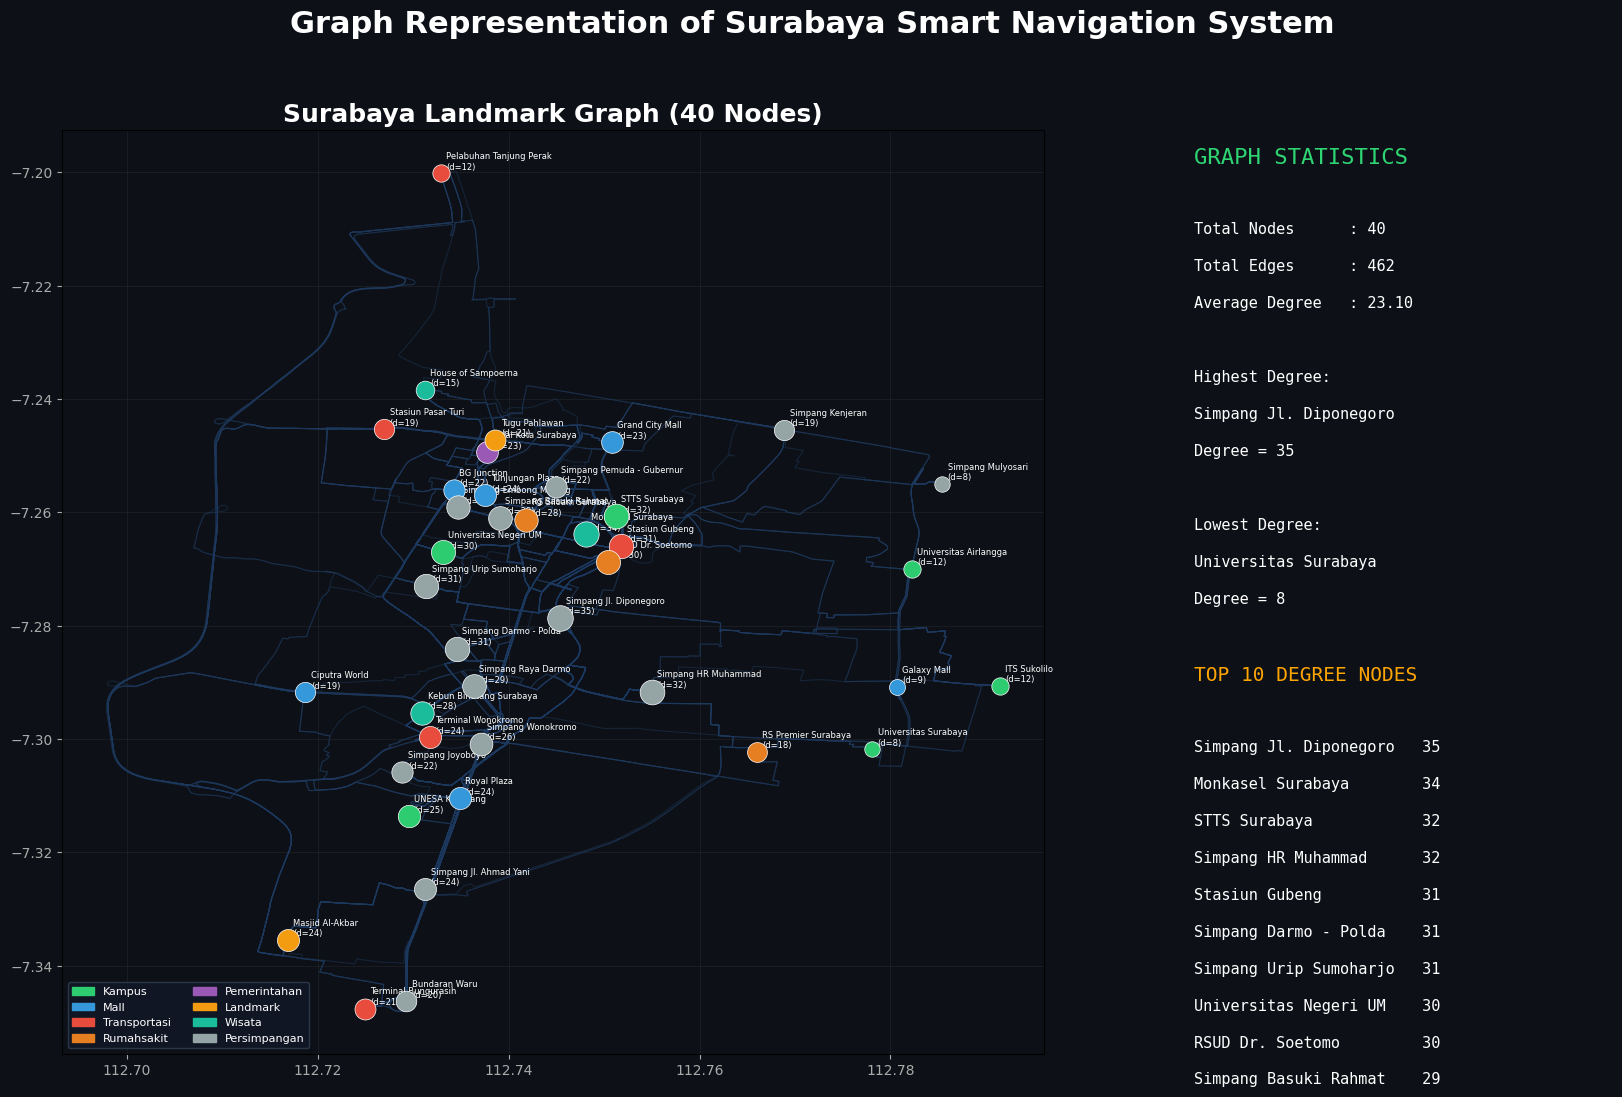

In [3]:
NODES, EDGES_RAW, GEOM = load_data()

graph = build_graph(NODES, EDGES_RAW)
show_surabaya_graph(
    graph,
    NODES,
    GEOM
)

# 4. Smart Navigation System Execution

This section combines all components into the final navigation system.

The program workflow:

1. Load processed graph data.
2. Select starting and destination locations.
3. Run Dijkstra, BFS, and DFS algorithms.
4. Compare algorithm performance based on:
   - Travel time
   - Route distance
   - Number of visited nodes
   - Execution time
5. Generate route visualization and comparison results.

The final result shows which algorithm provides the most efficient route in Surabaya's urban road network.


  SMART NAVIGATION SYSTEM — 40 NODE SURABAYA
  Dijkstra vs BFS vs DFS

   Memuat data dari CSV ...
   40 node, 462 edge, 462 polyline dimuat

  40 NODE SURABAYA:
   1. UNESA Ketintang                          [kampus]
   2. ITS Sukolilo                             [kampus]
   3. Universitas Airlangga                    [kampus]
   4. Universitas Surabaya                     [kampus]
   5. Universitas Negeri UM                    [kampus]
   6. STTS Surabaya                            [kampus]
   7. Tunjungan Plaza                          [mall]
   8. Grand City Mall                          [mall]
   9. Galaxy Mall                              [mall]
  10. BG Junction                              [mall]
  11. Ciputra World                            [mall]
  12. Royal Plaza                              [mall]
  13. Stasiun Gubeng                           [transportasi]
  14. Stasiun Pasar Turi                       [transportasi]
  15. Terminal Bungurasih                      [trans

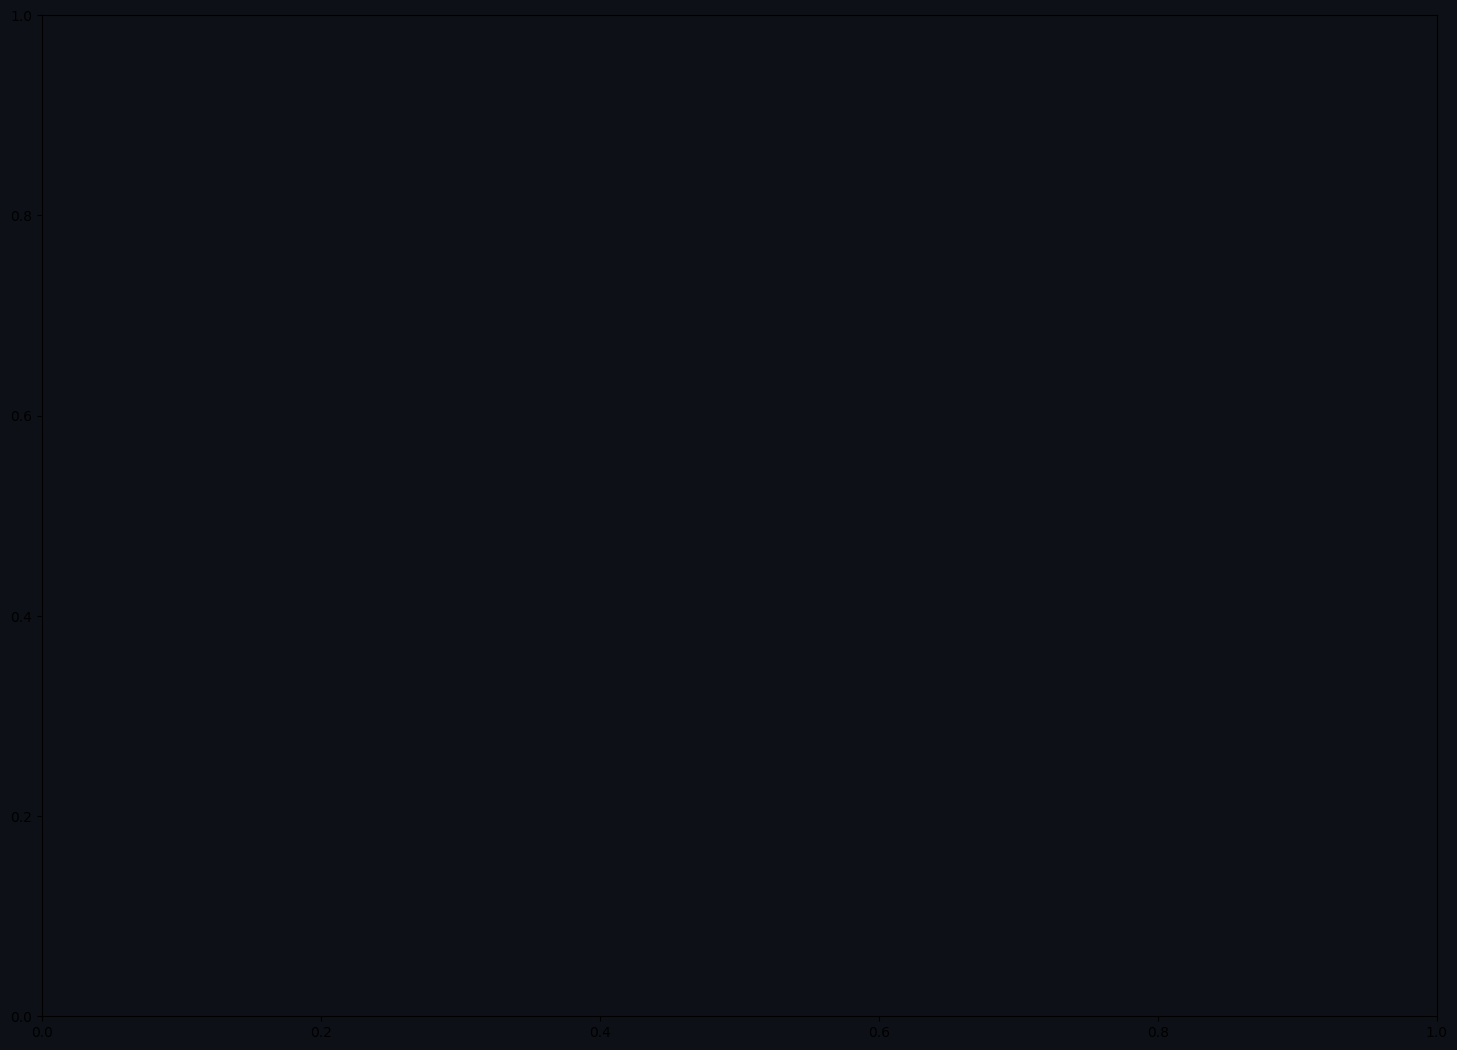

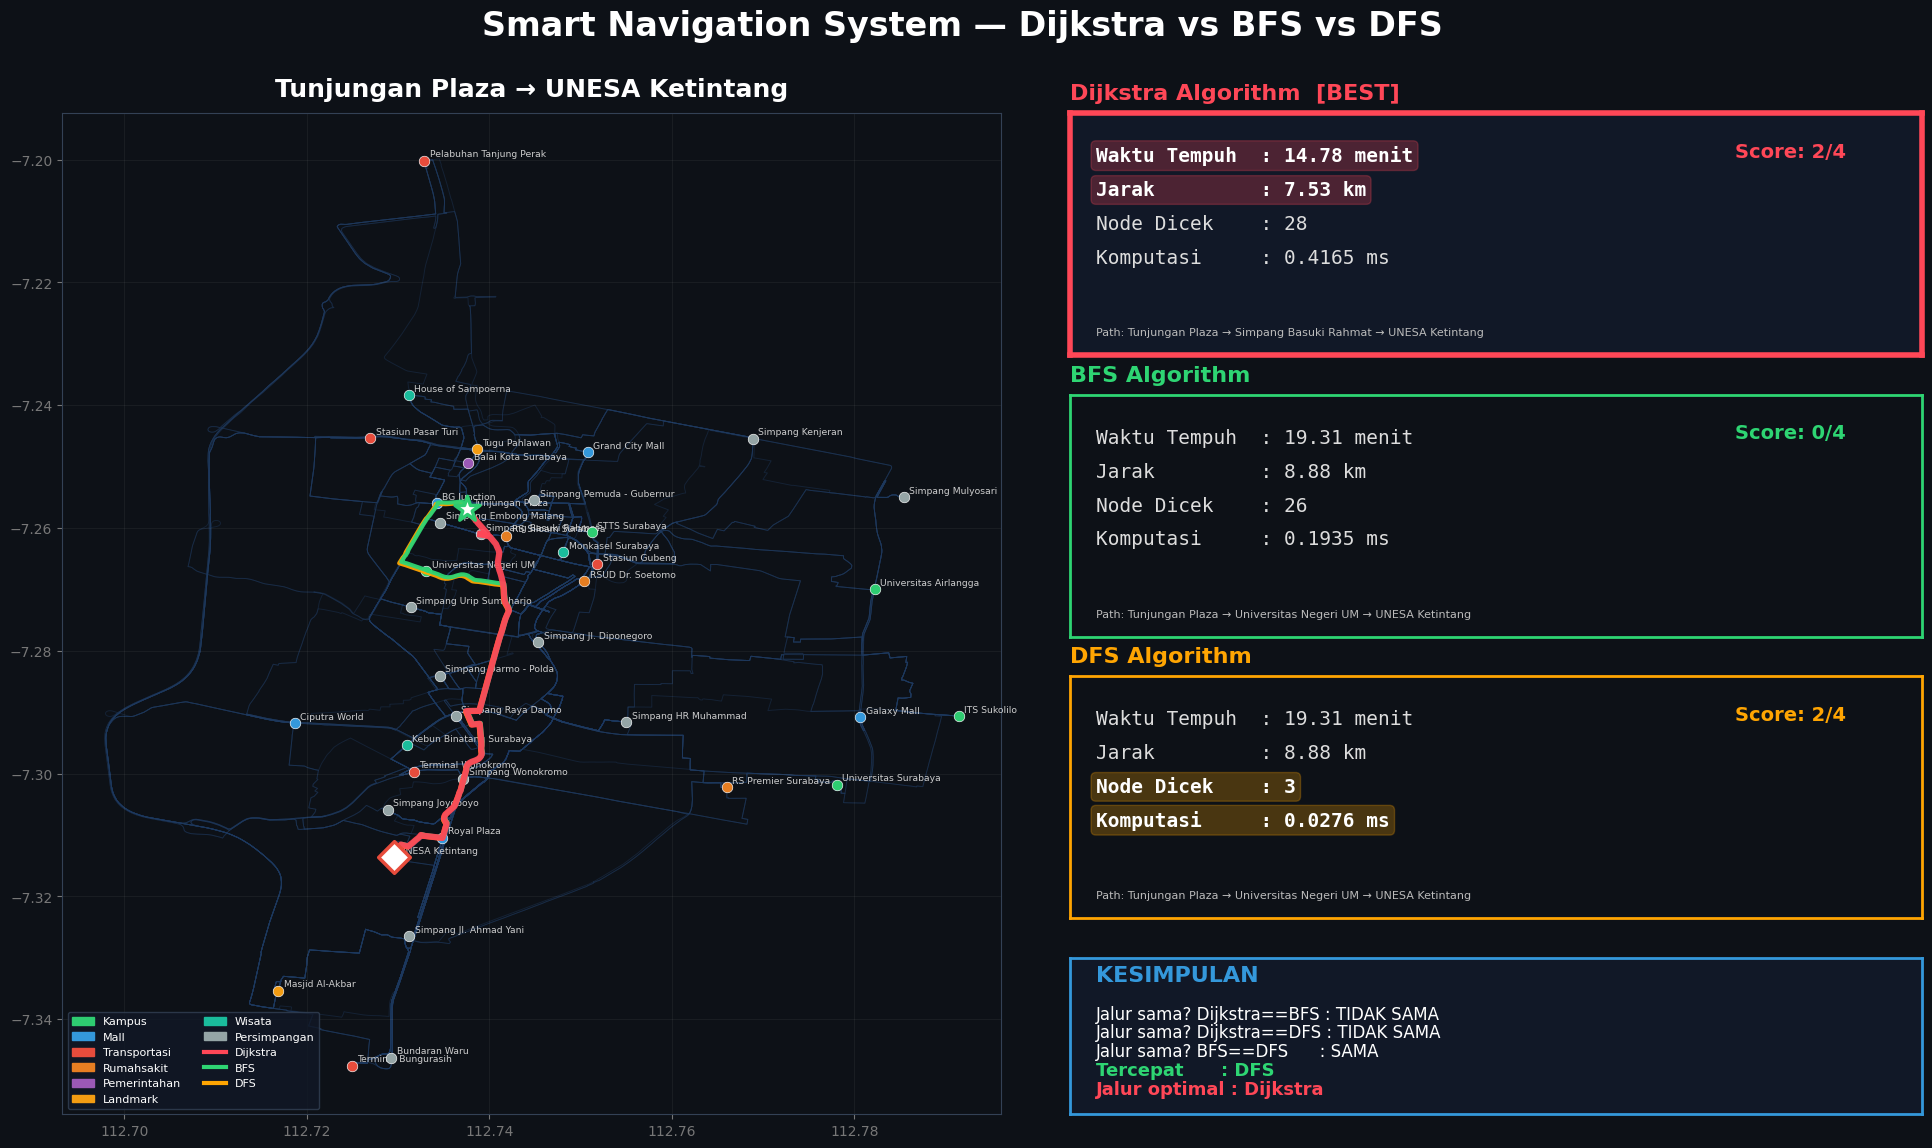


   Selesai. Output tersimpan di: output/


In [4]:
def main():
    print("\n" + "="*65)
    print("  SMART NAVIGATION SYSTEM — 40 NODE SURABAYA")
    print("  Dijkstra vs BFS vs DFS")
    print("="*65)

    # Cek CSV sudah ada
    for f in [NODES_CSV, EDGES_CSV]:
        if not os.path.exists(f):
            print(f"\n   File tidak ditemukan: {f}")
            return

    os.makedirs("output", exist_ok=True)

    print(f"\n   Memuat data dari CSV ...")
    NODES, EDGES_RAW, GEOM = load_data()
    print(f"   {len(NODES)} node, {len(EDGES_RAW)} edge, {len(GEOM)//2} polyline dimuat")

    graph = build_graph(NODES, EDGES_RAW)

    # Daftar node
    node_list = list(NODES.keys())
    print(f"\n  40 NODE SURABAYA:")
    for i, name in enumerate(node_list, 1):
        print(f"  {i:>2}. {name:<40} [{NODES[name]['type']}]")

    print(f"\n{'='*65}")
    print("INTERAKTIF: Masukkan nomor node ASAL dan TUJUAN untuk membandingkan algoritma")
    while True:
        s = input("\n  Nomor ASAL   (Enter untuk keluar): ").strip()
        if not s: break
        e = input("  Nomor TUJUAN : ").strip()
        try:
            start = node_list[int(s)-1]
            end   = node_list[int(e)-1]
            comp = compare_algorithms(graph,start,end)
            print_comparison(comp)
            animate_dijkstra_advanced(graph,NODES,GEOM,start,end)
            plot_comparison(comp, graph, NODES, GEOM, save_path=f"output/interaktif_{s}_{e}.png")
        except (IndexError, ValueError) as ex:
            print(f"Input tidak valid: {ex}")
        except KeyboardInterrupt:
            break

    print("\n   Selesai. Output tersimpan di: output/")

if __name__ == "__main__":
    main()